In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [2]:
airb=pd.read_csv("Airbnb_site_hotel_new.csv")
airb

,id,name,host_id,host_name,city,price,reply time,guest favourite,host since,host Certification,...,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales,area
0,1,Beautiful Victorian Home,1368256,Robert,Toronto,250,0.0,0,4563,1.0,...,47,6,"1,5",2,3,1,"0,9","0,42",102,North America
1,2,"World Class @ CN Tower, convention centre, The...",113345,Adela,Toronto,152,0.0,0,5120,1.0,...,42,4,1,1,2,5,"0,9","0,42",166,North America
2,3,Furnished room in lovely Annex house June -Oct31,1466410,Susan,Toronto,120,0.0,0,4534,1.0,...,0,1,1,1,2,2,1,"0,65",181,North America
3,4,Executive Studio Unit- Ideal for One Person,118124,Brent,Toronto,75,1.0,1,5111,1.0,...,29,1,1,0,1,1,1,1,365,North America
4,5,"Bright Beaches Apt, close to everything",175687,John,Toronto,90,0.0,0,5033,1.0,...,7,2,1,1,1,4,1,"0,8",328,North America
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86181,86182,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"87,5",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",273,Asia
86182,86183,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,330402207,葦靜,taipei,25,1.0,0,1559,1.0,...,0,1,0,0,1,34,1,"0,88",96,Asia
86183,86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"89,28125",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia
86184,86185,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,413599737,迪,taipei,"100,90625",1.0,0,1018,1.0,...,0,2,0,0,1,56,"0,99","0,99",274,Asia


In [3]:
airb.describe()

,id,host_id,reply time,guest favourite,host since,host Certification,room_type,host total listings count,total reviewers number,accommodates,bedrooms,beds,listing number,sales
count,86186.000000,8.618600e+04,66867.000000,86186.000000,86186.000000,82903.0,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000,86186.000000
mean,43093.500000,1.959076e+08,0.769857,0.273304,2380.740236,1.0,2.663959,23.492737,36.414174,3.412747,1.247407,1.914441,45.196772,183.385086
std,24879.899487,1.849803e+08,0.420928,0.445658,1269.305372,0.0,0.524877,73.067586,75.989911,2.393287,1.093598,1.732507,258.312637,119.302210
min,1.000000,1.581000e+03,0.000000,0.000000,0.000000,1.0,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,21547.250000,2.890381e+07,1.000000,0.000000,1422.000000,1.0,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,80.000000
50%,43093.500000,1.308280e+08,1.000000,0.000000,2540.000000,1.0,3.000000,3.000000,9.000000,2.000000,1.000000,1.000000,3.000000,193.000000
75%,64639.750000,3.492982e+08,1.000000,1.000000,3337.000000,1.0,3.000000,12.000000,37.000000,4.000000,2.000000,2.000000,15.000000,287.000000
max,86186.000000,5.752345e+08,1.000000,1.000000,5745.000000,1.0,4.000000,837.000000,2575.000000,16.000000,21.000000,60.000000,4818.000000,365.000000


In [4]:
airb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86186 entries, 0 to 86185
Data columns (total 23 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id                         86186 non-null  int64  
 1   name                       86186 non-null  object 
 2   host_id                    86186 non-null  int64  
 3   host_name                  86186 non-null  object 
 4   city                       86186 non-null  object 
 5   price                      80762 non-null  object 
 6   reply time                 66867 non-null  float64
 7   guest favourite            86186 non-null  int64  
 8   host since                 86186 non-null  int64  
 9   host Certification         82903 non-null  float64
 10  room_type                  86186 non-null  int64  
 11  host total listings count  86186 non-null  int64  
 12  consumer                   35421 non-null  object 
 13  total reviewers number     86186 non-null  int

# checking for missing values

In [5]:
airb.isnull().sum()

id                               0
name                             0
host_id                          0
host_name                        0
city                             0
price                         5424
reply time                   19319
guest favourite                  0
host since                       0
host Certification            3283
room_type                        0
host total listings count        0
consumer                     50765
total reviewers number           0
accommodates                     0
bathrooms                        0
bedrooms                         0
beds                             0
listing number                   0
host response rate               0
host acceptance rate             0
sales                            0
area                             0
dtype: int64

# checking for duplicate values

In [6]:
airb.duplicated().sum()

np.int64(0)

# splitting the work into categorical and continuous data

In [7]:
cat=airb.select_dtypes(include=["object"])
cat

,name,host_name,city,price,consumer,bathrooms,host response rate,host acceptance rate,area
0,Beautiful Victorian Home,Robert,Toronto,250,"6,81","1,5","0,9","0,42",North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,152,"6,67",1,"0,9","0,42",North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,120,0,1,1,"0,65",North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,75,"6,86",1,1,1,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,90,"6,57",1,1,"0,8",North America
...,...,...,...,...,...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"87,5",NaN,0,"0,99","0,99",Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,25,NaN,0,1,"0,88",Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"89,28125",NaN,0,"0,99","0,99",Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,"100,90625",NaN,0,"0,99","0,99",Asia


- Since the price column is displayed as an object, we are going to convert it to a float

In [8]:
airb['price'] = airb['price'].str.replace(',','').str.replace('$','').str.strip()
airb['price'] = airb['price'].astype(float)

In [9]:
airb['consumer'] = airb['consumer'].str.replace(',','').str.strip()
airb['consumer'] = airb['consumer'].astype(float)

In [10]:
airb['bathrooms'] = airb['bathrooms'].str.replace(',','').str.strip()
airb['bathrooms'] = airb['bathrooms'].astype(float)

In [11]:
airb['host response rate'] = airb['host response rate'].str.replace(',','').str.strip()
airb['host response rate'] = airb['host response rate'].astype(float)

In [12]:
airb['host acceptance rate'] = airb['host acceptance rate'].str.replace(',','').str.strip()
airb['host acceptance rate'] = airb['host acceptance rate'].astype(float)

In [13]:
categorical=airb.select_dtypes(include=['object'])
categorical

,name,host_name,city,area
0,Beautiful Victorian Home,Robert,Toronto,North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,North America
...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia


In [14]:
cont = airb.select_dtypes(exclude="object")
cont

,id,host_id,price,reply time,guest favourite,host since,host Certification,room_type,host total listings count,consumer,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales
0,1,1368256,NaN,0.0,0,4563,1.0,3,1,681.0,47,6,15.0,2,3,1,9.0,42.0,102
1,2,113345,NaN,0.0,0,5120,1.0,3,5,667.0,42,4,1.0,1,2,5,9.0,42.0,166
2,3,1466410,NaN,0.0,0,4534,1.0,2,1,0.0,0,1,1.0,1,2,2,1.0,65.0,181
3,4,118124,NaN,1.0,1,5111,1.0,3,1,686.0,29,1,1.0,0,1,1,1.0,1.0,365
4,5,175687,NaN,0.0,0,5033,1.0,3,1,657.0,7,2,1.0,1,1,4,1.0,8.0,328
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86181,86182,413599737,875.0,1.0,0,1018,1.0,3,13,NaN,0,2,0.0,0,1,56,99.0,99.0,273
86182,86183,330402207,25.0,1.0,0,1559,1.0,1,2,NaN,0,1,0.0,0,1,34,1.0,88.0,96
86183,86184,413599737,8928125.0,1.0,0,1018,1.0,3,13,NaN,0,2,0.0,0,1,56,99.0,99.0,274
86184,86185,413599737,10090625.0,1.0,0,1018,1.0,3,13,NaN,0,2,0.0,0,1,56,99.0,99.0,274


# Dealing with missing values

In [15]:
airb.isnull().sum()

id                               0
name                             0
host_id                          0
host_name                        0
city                             0
price                        38192
reply time                   19319
guest favourite                  0
host since                       0
host Certification            3283
room_type                        0
host total listings count        0
consumer                     50765
total reviewers number           0
accommodates                     0
bathrooms                        0
bedrooms                         0
beds                             0
listing number                   0
host response rate               0
host acceptance rate             0
sales                            0
area                             0
dtype: int64

In [16]:
airb['host Certification'].describe()

count    82903.0
mean         1.0
std          0.0
min          1.0
25%          1.0
50%          1.0
75%          1.0
max          1.0
Name: host Certification, dtype: float64

In [17]:
# starting with host Certification since it has the lowest missing values
airb['host Certification']= airb['host Certification'].fillna(airb['host Certification'].mean())

In [18]:
airb['reply time'].describe()

count    66867.000000
mean         0.769857
std          0.420928
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: reply time, dtype: float64

In [19]:
#reply time
airb['reply time'] = airb['reply time'].fillna(airb['reply time'].median())

- Since price and consumer have high number of missing values, we would've just deleted them but they may be important columns so we are going to impute for them using iterative imputer.
- A iterative imputer works in this way: each column that has missing values is regressed on other features and so themissing values are predicted until the model stabilizes.

In [20]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num_cols= airb.select_dtypes(include=[np.number]).columns
imputer = IterativeImputer(max_iter=10, random_state=42)

airb[num_cols]= imputer.fit_transform(airb[num_cols])

In [21]:
airb.isnull().sum()

id                           0
name                         0
host_id                      0
host_name                    0
city                         0
price                        0
reply time                   0
guest favourite              0
host since                   0
host Certification           0
room_type                    0
host total listings count    0
consumer                     0
total reviewers number       0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
listing number               0
host response rate           0
host acceptance rate         0
sales                        0
area                         0
dtype: int64

- We can see that we have dealt with all the missing values in our data. 


In [22]:
from scipy.stats import pearsonr, spearmanr, f_oneway
import seaborn as sns

# checking for and dealing with outliers

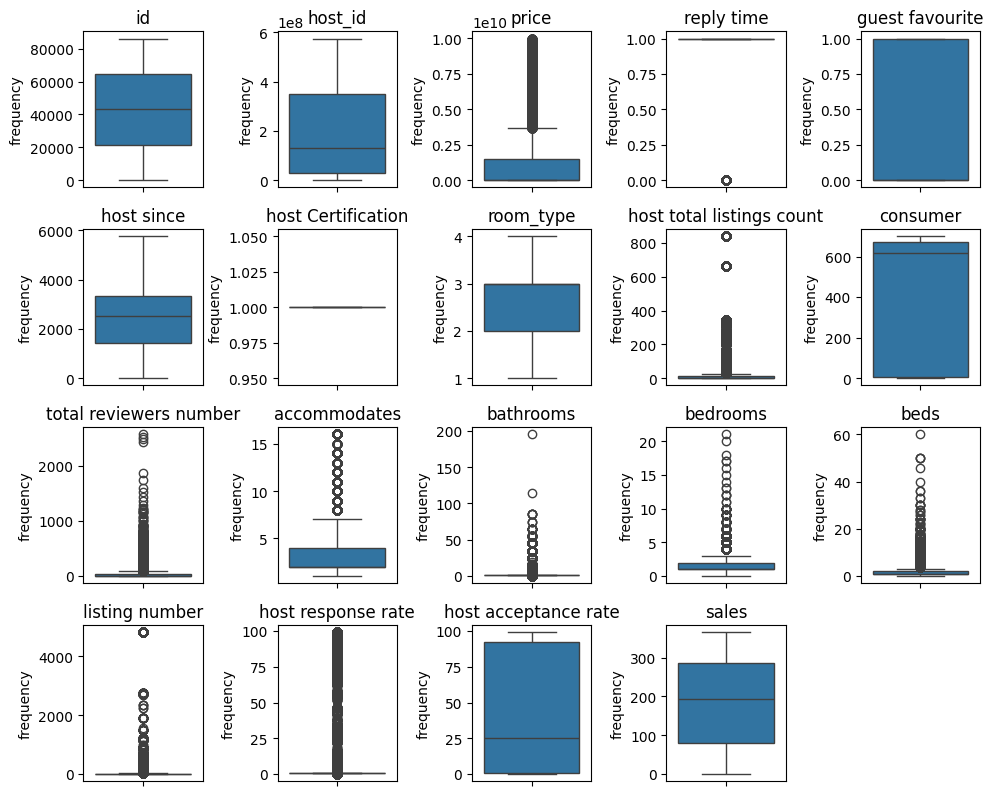

In [23]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont.columns):
    plt.subplot(5,5, i+1)
    sns.boxplot(cont[col])
    plt.title(col)
    plt.ylabel("frequency")
plt.tight_layout()
plt.show()

In [24]:
def remove_outliers(columns):
    for column in columns:

        upper_quartile=cont[column].quantile(.75)
        lower_quartile=cont[column].quantile(.25)

        IQR = upper_quartile - lower_quartile

        upper_boundary = upper_quartile + 1.5 * IQR
        lower_boundary = lower_quartile - 1.5 * IQR

        cont[column]= np.where(cont[column]>upper_boundary,upper_boundary,cont[column])
        cont[column]= np.where(cont[column]<lower_boundary,lower_boundary,cont[column])

In [25]:
remove_outliers(cont)

In [26]:
corr_matrix = cont.corr()
corr_matrix

,id,host_id,price,reply time,guest favourite,host since,host Certification,room_type,host total listings count,consumer,total reviewers number,accommodates,bathrooms,bedrooms,beds,listing number,host response rate,host acceptance rate,sales
id,1.000000,0.098421,0.163372,NaN,0.018683,-0.120604,NaN,0.100252,0.226733,-0.003711,-0.017943,0.180928,NaN,-0.130417,0.190206,0.213825,NaN,0.033723,0.095562
host_id,0.098421,1.000000,0.117867,NaN,0.006774,-0.970629,NaN,-0.009412,0.069169,-0.089183,-0.191749,0.045462,NaN,-0.002236,0.010878,0.059196,NaN,0.018849,-0.046873
price,0.163372,0.117867,1.000000,NaN,0.029934,-0.120467,NaN,-0.070605,0.214543,-0.161712,0.031080,-0.031440,NaN,0.094426,-0.029877,0.196289,NaN,0.022609,-0.055879
reply time,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guest favourite,0.018683,0.006774,0.029934,NaN,1.000000,-0.009381,NaN,0.053940,-0.097683,0.211021,0.194691,0.073780,NaN,0.057952,0.057313,-0.098524,NaN,0.087206,0.115908
host since,-0.120604,-0.970629,-0.120467,NaN,-0.009381,1.000000,NaN,0.008270,-0.070308,0.082319,0.184154,-0.047453,NaN,0.013001,-0.012310,-0.061502,NaN,-0.011624,0.038532
host Certification,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,0.100252,-0.009412,-0.070605,NaN,0.053940,0.008270,NaN,1.000000,-0.032954,0.071475,0.032924,0.424863,NaN,0.209884,0.275395,-0.022904,NaN,-0.006061,0.099216
host total listings count,0.226733,0.069169,0.214543,NaN,-0.097683,-0.070308,NaN,-0.032954,1.000000,-0.165185,-0.186605,-0.037556,NaN,-0.088980,0.000144,0.966442,NaN,0.191850,-0.181614
consumer,-0.003711,-0.089183,-0.161712,NaN,0.211021,0.082319,NaN,0.071475,-0.165185,1.000000,0.580937,0.019161,NaN,-0.064560,0.046851,-0.168402,NaN,0.115732,0.119956


In [27]:
target = airb['sales']

In [28]:
cont_cols = ['price', 'consumer', 'total reviewers number', 'accommodates',
             'bathrooms', 'bedrooms', 'beds', 'host acceptance rate']

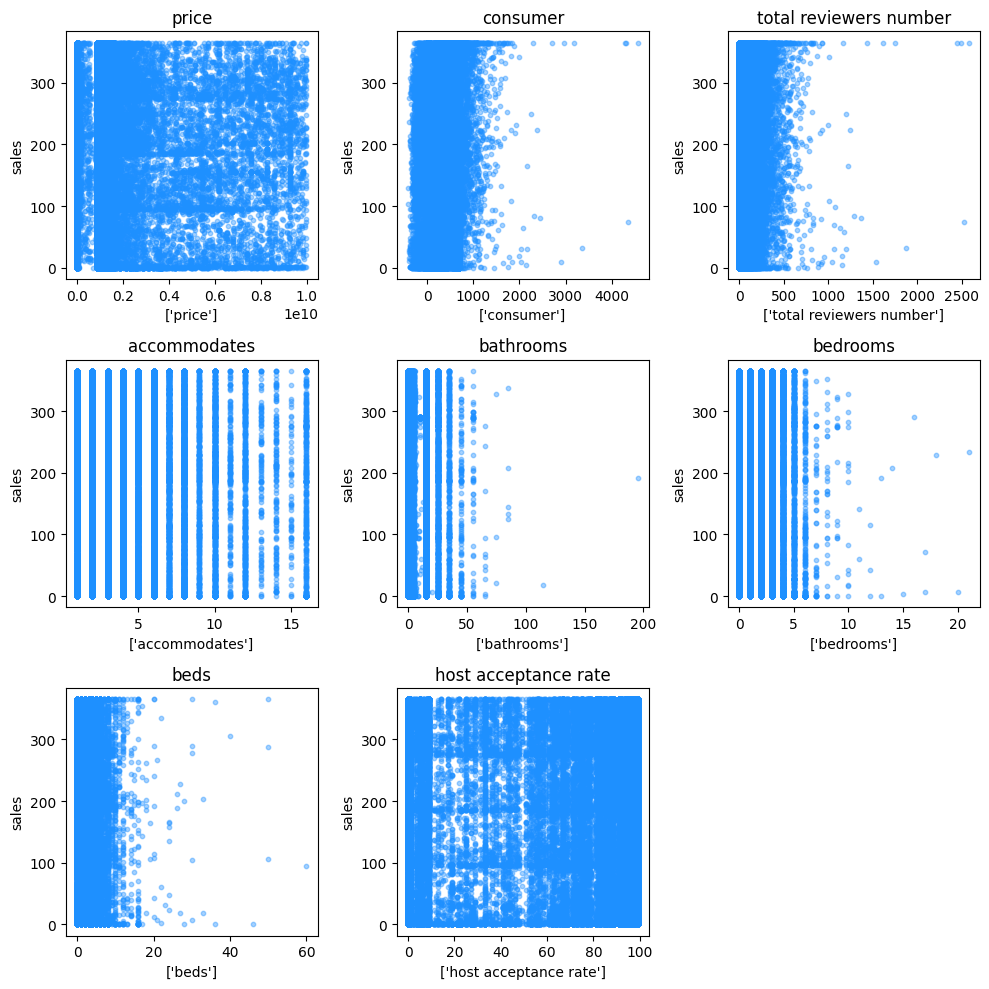

In [29]:
plt.figure(figsize=(10,10))
for i, col in enumerate(cont_cols,1):
    plt.subplot(3,3,i)
    plt.scatter(airb[col], airb['sales'], alpha=0.4, s=10, color='dodgerblue')
    plt.title(col)
    plt.ylabel("sales")
    plt.xlabel([col])
plt.tight_layout()
plt.show()

- Correlation between categorical variables and the target variable

In [30]:
categorical

,name,host_name,city,area
0,Beautiful Victorian Home,Robert,Toronto,North America
1,"World Class @ CN Tower, convention centre, The...",Adela,Toronto,North America
2,Furnished room in lovely Annex house June -Oct31,Susan,Toronto,North America
3,Executive Studio Unit- Ideal for One Person,Brent,Toronto,North America
4,"Bright Beaches Apt, close to everything",John,Toronto,North America
...,...,...,...,...
86181,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86182,Rental unit in 三愛里 · ★New · 1 bedroom · 1 bed ...,葦靜,taipei,Asia
86183,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia
86184,Rental unit in 江山里 · ★New · 1 bedroom · 1 bed ...,迪,taipei,Asia


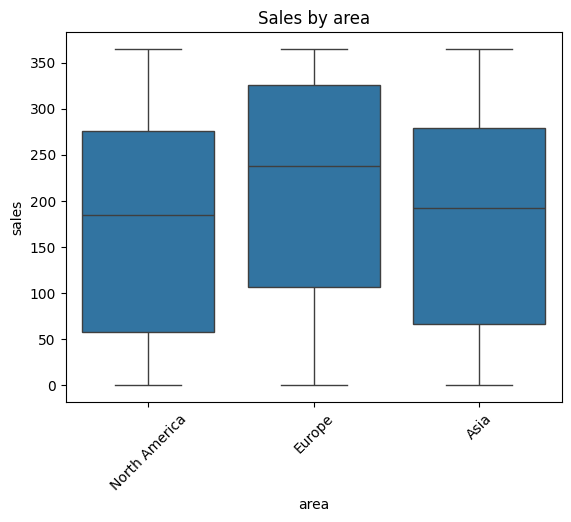

In [31]:
sns.boxplot(data=airb, x='area', y='sales')
plt.title('Sales by area')
plt.xticks(rotation=45)
plt.show()

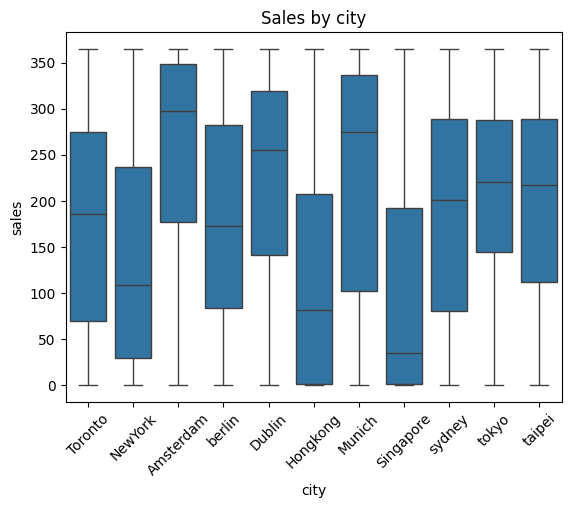

In [32]:
sns.boxplot(data=airb, x='city', y='sales')
plt.title('Sales by city')
plt.xticks(rotation=45)
plt.show()

In [40]:
def Anova_test(data,var1,var2):
    group_data=[
        group[var1].values for _, group in data.groupby(var2)
    ]
    f_stats,p_value =f_oneway(*group_data)

    if p_value > 0.05:
        print(f"{var1} is not significantly correlated with {var2}")
    else:
        print(f"{var1} is significantly correlated with {var2}")

    print(p_value)
    print(f_stats)

In [41]:
Anova_test(airb,"sales","area")

sales is significantly correlated with area
0.0
1193.6966727496997


In [42]:
Anova_test(airb,"sales","city")

sales is significantly correlated with city
0.0
1022.7173326607543


In [43]:
Anova_test(airb,"sales","host_name")

sales is significantly correlated with host_name
0.0
3.554579657000524


In [44]:
Anova_test(airb,"sales","name")

sales is significantly correlated with name
1.9055511291212927e-152
1.5235370320276544


# encoding the categorical variables

In [46]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [47]:
airb['city_encoded'] = airb.groupby('city')['sales'].transform('mean')
airb['area_encoded'] = airb.groupby('area')['sales'].transform('mean')
airb['name_encoded'] = airb.groupby('name')['sales'].transform('mean')
airb['hostname_encoded'] = airb.groupby('host_name')['sales'].transform('mean')

# Regression models

In [51]:
X = airb[['city_encoded','area_encoded','name_encoded','price', 'consumer', 'total reviewers number', 'accommodates',
             'bathrooms', 'bedrooms', 'beds', 'host acceptance rate']]
y= target

- splitting the data into train and test set

In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((68948, 11), (17238, 11))

# Linear regression

In [72]:
x_linear = X[['city_encoded']]
y = target

In [73]:
X_train, X_test, y_train, y_test = train_test_split(x_linear,y,test_size=0.2, random_state=42)

- the model

In [74]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)

LinearRegression()

- making predictions

In [75]:
y_pred = linear_reg.predict(X_test)

- model evaluation

In [76]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}, \nMSE: {mse:.3f}, \nR^2: {r2:.3f}")

MAE: 97.055, 
MSE: 12699.344, 
R^2: 0.108


- visualization of the linear regression model performance

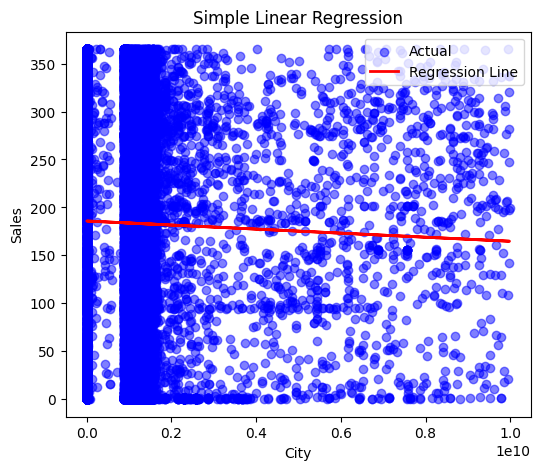

In [65]:
plt.figure(figsize=(6,5))
plt.scatter(X_test, y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("Simple Linear Regression")
plt.legend()
plt.show()

In [66]:
X.corr()

,city_encoded,area_encoded,name_encoded,price,consumer,total reviewers number,accommodates,bathrooms,bedrooms,beds,host acceptance rate
city_encoded,1.000000,0.504061,0.338497,-0.076104,0.103371,0.106721,0.110457,0.109792,0.035516,0.097314,-0.011977
area_encoded,0.504061,1.000000,0.170194,-0.112464,0.121914,0.083401,-0.080362,0.015318,-0.115482,-0.017282,-0.037194
name_encoded,0.338497,0.170194,1.000000,-0.031659,0.146088,0.097195,0.038739,0.030809,0.002735,0.019434,0.036585
price,-0.076104,-0.112464,-0.031659,1.000000,-0.415796,-0.011685,-0.022788,0.013267,0.024497,-0.023312,0.019740
consumer,0.103371,0.121914,0.146088,-0.415796,1.000000,0.526369,0.037425,-0.030251,-0.052750,0.058536,0.112656
total reviewers number,0.106721,0.083401,0.097195,-0.011685,0.526369,1.000000,0.017622,-0.001100,-0.020768,0.041390,0.031270
accommodates,0.110457,-0.080362,0.038739,-0.022788,0.037425,0.017622,1.000000,0.236417,0.585003,0.720641,-0.008640
bathrooms,0.109792,0.015318,0.030809,0.013267,-0.030251,-0.001100,0.236417,1.000000,0.380192,0.200095,-0.026959
bedrooms,0.035516,-0.115482,0.002735,0.024497,-0.052750,-0.020768,0.585003,0.380192,1.000000,0.477467,-0.037873
beds,0.097314,-0.017282,0.019434,-0.023312,0.058536,0.041390,0.720641,0.200095,0.477467,1.000000,-0.005656


# Multiple linear regression

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
linear_reg_multi = LinearRegression()
linear_reg_multi.fit(X_train_scaled, y_train)

## making predictions
y_pred_multi = linear_reg_multi.predict(X_test_scaled)

In [80]:
### model evaluation
mae_m = mean_absolute_error(y_test, y_pred_multi)
mse_m = mean_squared_error(y_test, y_pred_multi)
r2_m = r2_score(y_test, y_pred_multi)

print(f"\nMAE: {mae_m:.3f},\nMSE: {mse_m:.3f},\nR²: {r2_m:.3f}")


MAE: 9.159,
MSE: 1064.664,
R²: 0.925


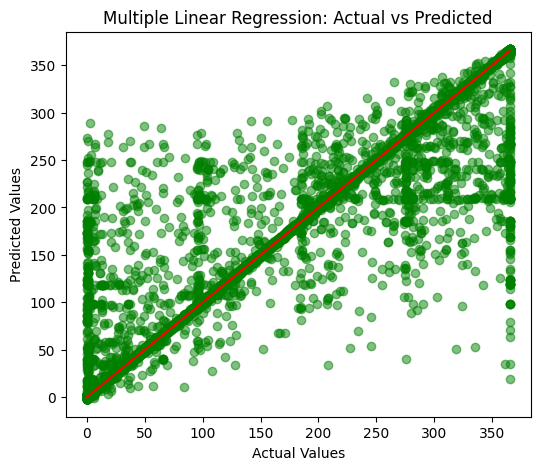

In [81]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_multi, color='green', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r-')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.show()

- the individual feature contributions to the predictions

In [82]:
coeffs = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": linear_reg_multi.coef_
}).sort_values("Coefficient", ascending=False)

coeffs

,Feature,Coefficient
2,name_encoded,114.397648
4,consumer,1.315712
3,price,0.553119
0,city_encoded,0.080567
1,area_encoded,0.069164
9,beds,0.063684
7,bathrooms,0.005168
8,bedrooms,-0.020071
6,accommodates,-0.045677
10,host acceptance rate,-0.385569


# Decision tree regressor

In [84]:
tree = DecisionTreeRegressor(max_depth=6, random_state=42)
tree.fit(X_train, y_train)
y_pred_tr = tree.predict(X_test)
mae_tr = mean_absolute_error(y_test, y_pred_tr)
mse_tr = mean_squared_error(y_test, y_pred_tr)
rmse_tr = root_mean_squared_error(y_test, y_pred_tr)
r2_tr = r2_score(y_test, y_pred_tr)
print(f'MAE: {mae_tr:.4f} \nMSE: {mse_tr:.4f} \nRMSE: {rmse_tr:.4f} \nR2: {r2_tr:.2f}') 

MAE: 10.9108 
MSE: 997.4885 
RMSE: 31.5830 
R2: 0.93


In [93]:
feature_names = X.columns

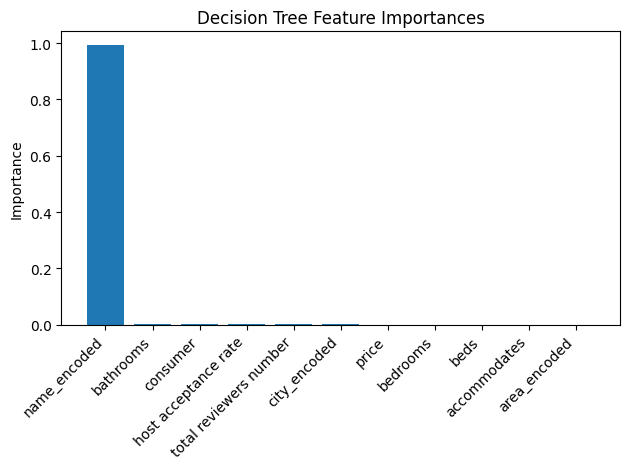

In [94]:
importances = tree.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure()
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), np.array(feature_names)[indices], rotation=45, ha='right')
plt.ylabel('Importance')
plt.title('Decision Tree Feature Importances')
plt.tight_layout()
plt.show()